In [2]:
# ===================================================
# Step 1: Import Libraries
# ===================================================
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay


## Reading Dataset


In [3]:
# ===================================================
# Step 2: Load the BEED dataset
# ===================================================
data = pd.read_csv('BEED_Data.csv')  

df = pd.DataFrame(data)         # Convert the loaded data into a pandas DataFrame

# Split features/target
X = df.drop('y', axis=1)        # Features
y = df['y']                     # Target

# Quick check
print("X shape:",X.shape)
print("y shape", y.shape)
print("Data shape: ",df.shape)

print(df.head())
print(df.info())
print(df['y'].value_counts())

print(df.describe().T)


X shape: (8000, 16)
y shape (8000,)
Data shape:  (8000, 17)
    X1   X2   X3   X4   X5   X6  X7  X8  X9  X10  X11  X12  X13  X14  X15  \
0    4    7   18   25   28   27  20  10 -10  -18  -20  -16   13   32   12   
1   87  114  120  106   76   54  28   5 -19  -49  -85 -102 -100  -89  -61   
2 -131 -133 -140 -131 -123 -108 -58 -51 -70  -77  -76  -76  -73  -57  -40   
3   68  104   73   34  -12  -26 -38 -36 -67  -88  -25   31   18   -4    6   
4  -67  -90  -97  -94  -86  -71 -43 -11  23   46   58   50   39   19   -9   

   X16  y  
0   10  0  
1  -21  0  
2  -14  0  
3  -29  0  
4  -41  0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      8000 non-null   int64
 1   X2      8000 non-null   int64
 2   X3      8000 non-null   int64
 3   X4      8000 non-null   int64
 4   X5      8000 non-null   int64
 5   X6      8000 non-null   int64
 6   X7      8000 

## Cleansing Data

In [4]:
# ===================================================
# Step 3: Preparing Data
# ===================================================

# Count number of missing values
missing = df.isnull().sum()
print(missing)



X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
y      0
dtype: int64


In [5]:
# ===================================================
# Step 4: Feature Engineering
# ===================================================
# Create new informative features using domain knowledge or transformations.

# Add simple engineered features across channels (works well and is easy to justify)
X_fe = X.copy()
X_fe["mean_signal"] = X.mean(axis=1)
X_fe["std_signal"]  = X.std(axis=1)
X_fe["max_signal"]  = X.max(axis= 1)
X_fe["min_signal"]  = X.min(axis=1)
X_fe["Signal_energy"] = (X**2).sum(axis=1)

print("Engineered feature columns added:", [c for c in X_fe.columns if c not in X.columns])


Engineered feature columns added: ['mean_signal', 'std_signal', 'max_signal', 'min_signal', 'Signal_energy']


## Split the Data

In [6]:
# ===================================================
# Step 5: Train / Test Split (Stratified)
# ===================================================

# split data into training and testing sets
# 80% train_val, 20% test
X_train, X_test, y_train, y_test = train_test_split(X_fe, y, test_size=0.20, random_state=42, stratify=y)

print("Split sizes:")
print("Train:", X_train.shape, "Test:",X_test.shape)


Split sizes:
Train: (6400, 21) Test: (1600, 21)


In [7]:
# ===================================================
# Step 6: Hyperparameter Tuning
# ===================================================

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ===================================================
# A) Logistic Regression
# ===================================================

logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),    # Standardize features
    ("pca", PCA()),                  # Apply PCA for dimensionality reduction
    ("clf", LogisticRegression(random_state=42))
])

# Define the hyperparameter search space for GridSearchCV
logreg_params = {
    "pca__n_components": [0.90, 0.95, 0.99], # Retain 90%, 95%, or 99% of the variance using PCA
    "clf__C": [0.01, 0.1, 1, 10],            # Regularization strength
    "clf__penalty": ["l2"],                  # L2 regularization
    "clf__solver": ["lbfgs", "liblinear"],   # Optimization solvers
    "clf__max_iter": [2000]                  # Maximum iterations
}

# Perform grid search with cross-validation
logreg_grid = GridSearchCV(
    estimator=logreg_pipe,          # Pipeline as the estimator
    param_grid=logreg_params,       # Hyperparameter combinations
    cv=cv5,                         # 5-fold cross-validation
    scoring="accuracy",             # Evaluation metric
    n_jobs=-1                       # Use all available CPU cores
)

logreg_grid.fit(X_train, y_train)   # Use unscaled X_train (pipeline scales inside CV)
print("Best Logistic Regression:", logreg_grid.best_params_)
print("Best LR CV Accuracy:", logreg_grid.best_score_)


# ===================================================
# B) SVM Classifier
# ===================================================

# Create an SVM pipeline
svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", SVC(probability=True))
])

# Define hyperparameter grid for different SVM kernels
svm_params = [
    # Linear kernel parameters
    {"pca__n_components": [0.90, 0.95, 0.99],
     "clf__kernel": ["linear"], "clf__C": [0.1, 1, 10]},

    # RBF kernel parameters
    {"pca__n_components": [0.90, 0.95, 0.99],
     "clf__kernel": ["rbf"], "clf__C": [0.1, 1, 10],
     "clf__gamma": ["scale", "auto"]},

    # Polynomial kernel parameters
    {"pca__n_components": [0.90, 0.95, 0.99],
     "clf__kernel": ["poly"], "clf__C": [0.1, 1, 10],
     "clf__gamma": ["scale", "auto"]}
]

# Perform grid search with cross-validation
svm_grid = GridSearchCV(
    estimator=svm_pipe,     # SVM pipeline
    param_grid=svm_params,  # Parameter combinations
    cv=cv5,                 # 5-fold cross-validation
    scoring="accuracy",     # Evaluation metric
    n_jobs=-1               # Use all CPU cores
)

# Train the model
svm_grid.fit(X_train, y_train)
print("Best SVM Parameters:", svm_grid.best_params_)
print("Best SVM CV Accuracy:", svm_grid.best_score_)


# ===================================================
# C) MLP Neural Network
# ===================================================

# Define the MLPClassifier
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
    ("clf", MLPClassifier(
        solver="adam",
        max_iter=300,
        random_state=42,
        early_stopping=True
    ))
])

# Define hyperparameter grid
mlp_params = {
    "pca__n_components": [0.90, 0.95, 0.99],
    "clf__hidden_layer_sizes": [(128, 64), (64, 32), (128, 128, 64)],
    "clf__activation": ["relu", "tanh"],
    "clf__alpha": [0.0001, 0.001, 0.01],
    "clf__learning_rate": ["constant", "adaptive"],
    "clf__batch_size": [32, 64]
}

# Create GridSearchCV
mlp_grid = GridSearchCV(
    estimator=mlp_pipe,       # The base model to tune (MLPClassifier)
    param_grid=mlp_params,    # Dictionary of hyperparameters to try
    cv= cv5,                  # 5-fold cross-validation:
                              # Data is split into 5 parts; each part is used once as validation
                              # while the other 4 parts train the model
    scoring='accuracy',       # Metric to evaluate performance of each hyperparameter combination
    verbose=2,                # Level of logging: 2 = detailed progress output
    n_jobs=-1                 # Use all CPU cores to parallelize grid search
)

mlp_grid.fit(X_train, y_train)
print("Best MLP Parameters:", mlp_grid.best_params_)
print("Best MLP CV Accuracy:", mlp_grid.best_score_)


# ===================================================
# Pick the best model automatically
# ===================================================
best = max(
    [("LogReg", logreg_grid), ("MLP", mlp_grid), ("SVM", svm_grid)],
    key=lambda t: t[1].best_score_
)

print("\nOverall Best Model:", best[0])
print("Overall Best Params:", best[1].best_params_)
print("Overall Best CV Accuracy:", best[1].best_score_)


C:\Users\user\ML\Lib\site-packages\sklearn\linear_model\_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(


Best Logistic Regression: {'clf__C': 1, 'clf__max_iter': 2000, 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'pca__n_components': 0.99}
Best LR CV Accuracy: 0.64421875
Best SVM Parameters: {'clf__C': 10, 'clf__gamma': 'auto', 'clf__kernel': 'rbf', 'pca__n_components': 0.99}
Best SVM CV Accuracy: 0.81171875
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best MLP Parameters: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__batch_size': 64, 'clf__hidden_layer_sizes': (128, 128, 64), 'clf__learning_rate': 'constant', 'pca__n_components': 0.99}
Best MLP CV Accuracy: 0.9389062499999999

Overall Best Model: MLP
Overall Best Params: {'clf__activation': 'relu', 'clf__alpha': 0.0001, 'clf__batch_size': 64, 'clf__hidden_layer_sizes': (128, 128, 64), 'clf__learning_rate': 'constant', 'pca__n_components': 0.99}
Overall Best CV Accuracy: 0.9389062499999999


In [8]:
# ===================================================
# Step 7: Best models
# ===================================================

logreg_best = logreg_grid.best_estimator_
svm_best = svm_grid.best_estimator_
mlp_best = mlp_grid.best_estimator_

# Create a dictionary for easy iteration
best_models = {
    "Logistic Regression": logreg_best,
    "SVM": svm_best,
    "MLP Neural Network": mlp_best
}

print("-" * 60)
print(f"{'Model Name':<25} | {'Best Estimator / Parameters'}")
print("-" * 60)

for name, model in best_models.items():
    # model.get_params() gives you a dict of the parameters
    # We convert it to a string or just print the model object which has a nice repr
    print(f"{name:<25} | {model}")
    print("-" * 60)
    

------------------------------------------------------------
Model Name                | Best Estimator / Parameters
------------------------------------------------------------
Logistic Regression       | Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.99)),
                ('clf',
                 LogisticRegression(C=1, max_iter=2000, random_state=42,
                                    solver='liblinear'))])
------------------------------------------------------------
SVM                       | Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.99)),
                ('clf', SVC(C=10, gamma='auto', probability=True))])
------------------------------------------------------------
MLP Neural Network        | Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.99)),
                ('clf',
                 MLPClassifier(batch_size=64, early_stopping=True,
                               hidden_layer_sizes=(128, 128, 64


Results for Fine-Tuned Logistic Regression
Training Accuracy: 0.646875
Test Accuracy: 0.6275

Confusion Matrix (Test):
[[377  15   1   7]
 [ 12 249  60  79]
 [  3  42 292  63]
 [  7 102 205  86]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     0.9449    0.9425    0.9437       400
           1     0.6103    0.6225    0.6163       400
           2     0.5233    0.7300    0.6096       400
           3     0.3660    0.2150    0.2709       400

    accuracy                         0.6275      1600
   macro avg     0.6111    0.6275    0.6101      1600
weighted avg     0.6111    0.6275    0.6101      1600



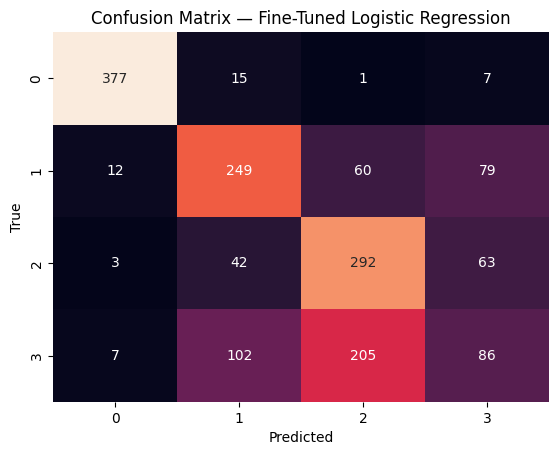


Results for Fine-Tuned SVM Classifier
Training Accuracy: 0.82375
Test Accuracy: 0.815625

Confusion Matrix (Test):
[[397   2   0   1]
 [  0 330  41  29]
 [  0   8 368  24]
 [  0  40 150 210]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     1.0000    0.9925    0.9962       400
           1     0.8684    0.8250    0.8462       400
           2     0.6583    0.9200    0.7675       400
           3     0.7955    0.5250    0.6325       400

    accuracy                         0.8156      1600
   macro avg     0.8305    0.8156    0.8106      1600
weighted avg     0.8305    0.8156    0.8106      1600



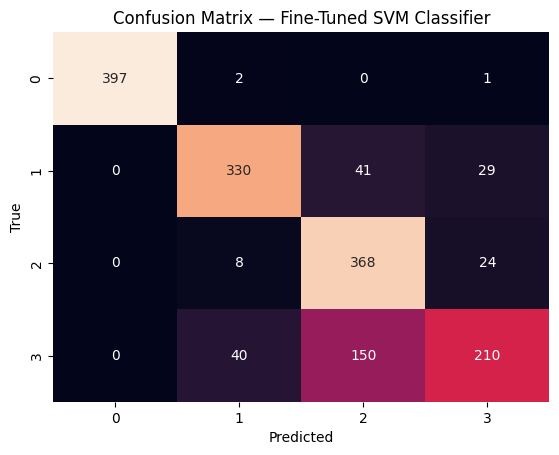


Results for Fine-Tuned MLP Neural Network
Training Accuracy: 0.9875
Test Accuracy: 0.95125

Confusion Matrix (Test):
[[398   1   0   1]
 [  0 379   6  15]
 [  0  10 373  17]
 [  0   4  24 372]]

Classification Report (Test):
              precision    recall  f1-score   support

           0     1.0000    0.9950    0.9975       400
           1     0.9619    0.9475    0.9547       400
           2     0.9256    0.9325    0.9290       400
           3     0.9185    0.9300    0.9242       400

    accuracy                         0.9513      1600
   macro avg     0.9515    0.9513    0.9513      1600
weighted avg     0.9515    0.9513    0.9513      1600



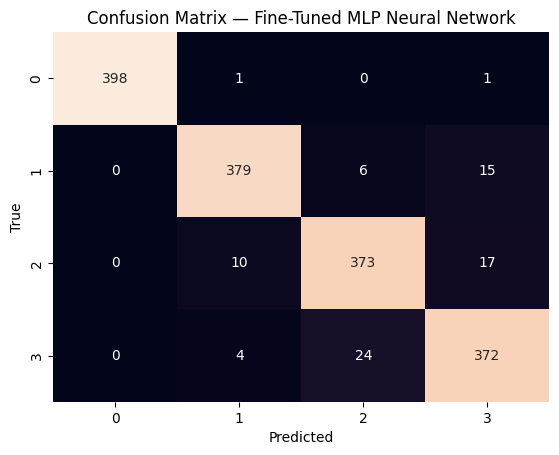

In [9]:
# =============================================================
# Step 8: Evaluate All Models
# =============================================================

# Evaluation Function
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    print("\n" + "="*60)
    print(f"Results for {name}")
    print("="*60)

    # Predict labels for training and test data
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)

    # Print accuracy on training/testing data
    print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
    print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

    # Display confusion matrix for test data
    print("\nConfusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))

    # Display precision, recall, F1-score for each class
    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, digits=4))
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

#Evaluate All Models
evaluate_model(logreg_best, X_train, X_test, y_train, y_test,
               "Fine-Tuned Logistic Regression")

evaluate_model(svm_best, X_train, X_test, y_train, y_test,
               "Fine-Tuned SVM Classifier")

evaluate_model(mlp_best, X_train, X_test, y_train, y_test,
               "Fine-Tuned MLP Neural Network")


<Figure size 640x480 with 0 Axes>

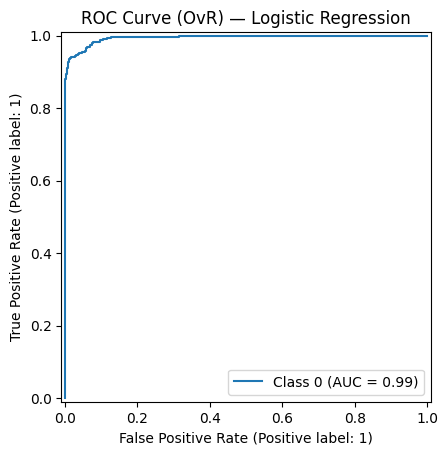

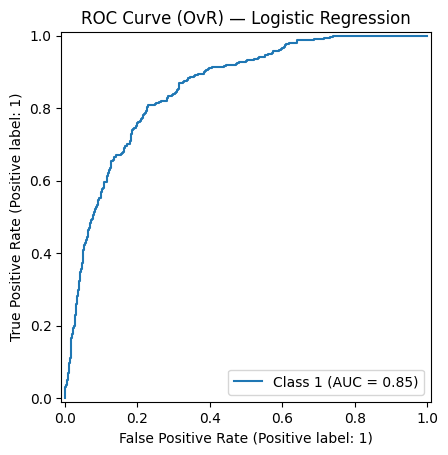

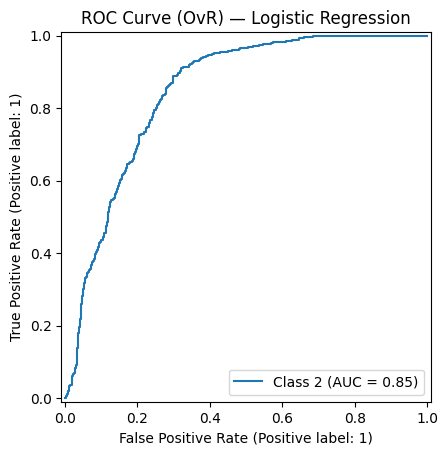

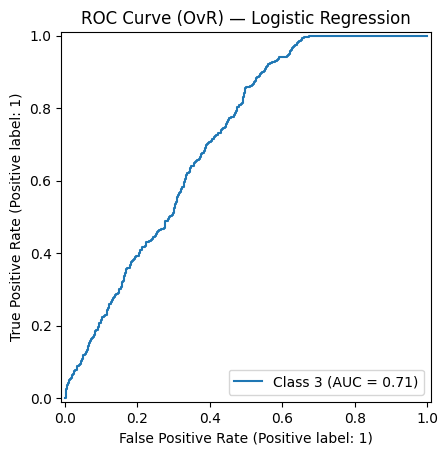

<Figure size 640x480 with 0 Axes>

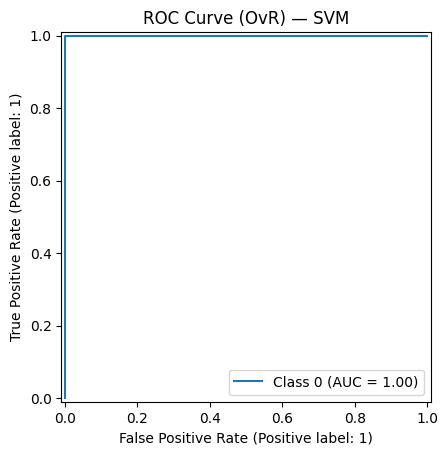

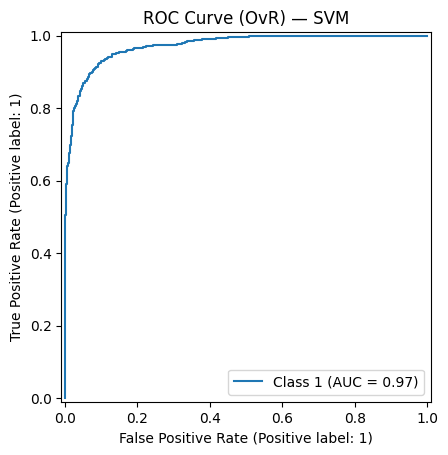

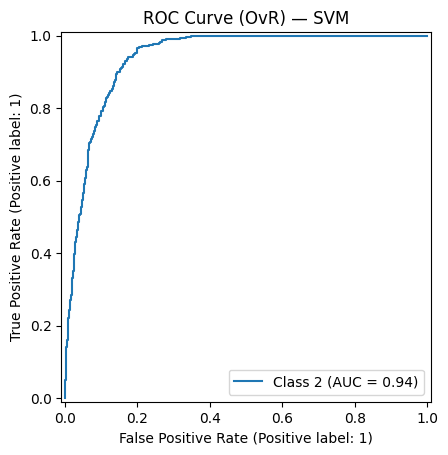

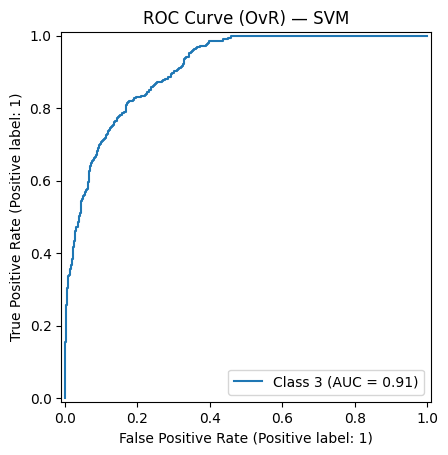

<Figure size 640x480 with 0 Axes>

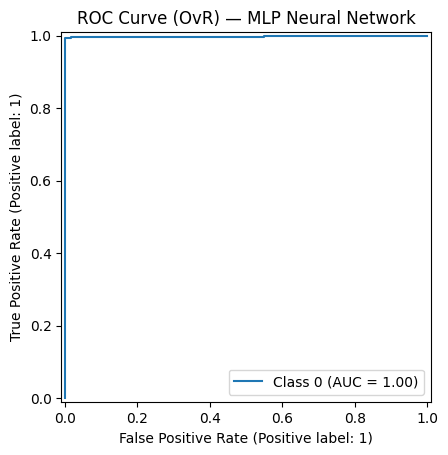

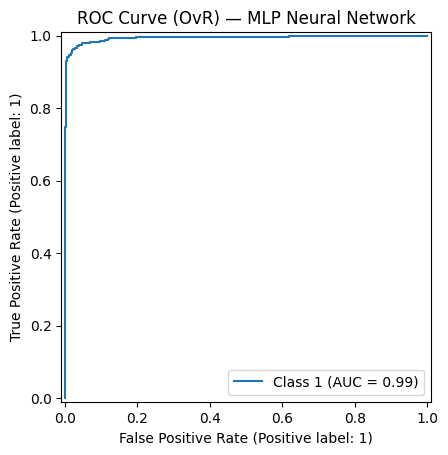

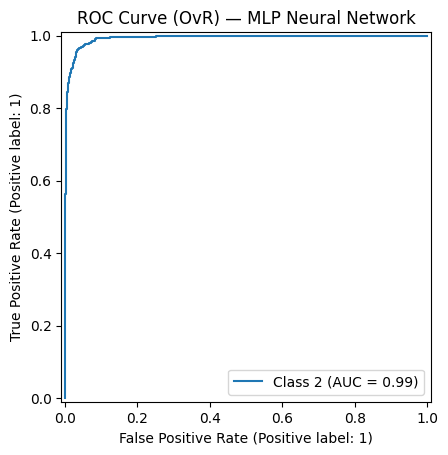

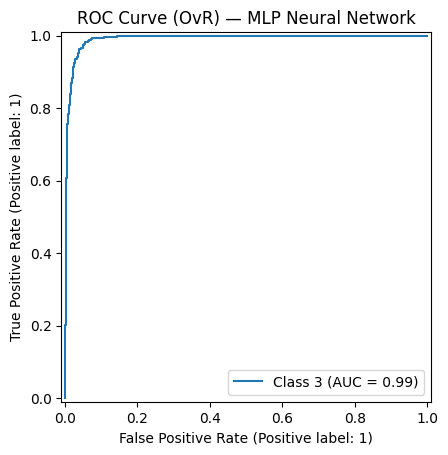

In [19]:

# Function to plot ROC curves for multiclass classification (One-vs-Rest)
def plot_multiclass_roc(model, X_test, y_test, name):
    
    # Get unique class labels
    classes = np.unique(y_test)
    
    # Convert true labels to binary format for ROC computation
    y_test_bin = label_binarize(y_test, classes=classes)

    # Get prediction scores
    # Use predict_proba if available, otherwise use decision_function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)
    else:
        y_score = model.decision_function(X_test)

    # Create a new figure for ROC curves
    plt.figure()
    
    # Plot ROC curve for each class
    for i, c in enumerate(classes):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i],   # True binary labels for class c
            y_score[:, i],      # Predicted scores for class c
            name=f"Class {c}",
        )
        # Set plot title
        plt.title(f"ROC Curve (OvR) — {name}")
    
    # Show the plot
    plt.show()

# Plot ROC curves for Logistic Regression
plot_multiclass_roc(logreg_best, X_test, y_test, "Logistic Regression")

# Plot ROC curves for SVM
plot_multiclass_roc(svm_best, X_test, y_test, "SVM")

# Plot ROC curves for ANN (MLP)
plot_multiclass_roc(mlp_best, X_test, y_test, "MLP Neural Network")


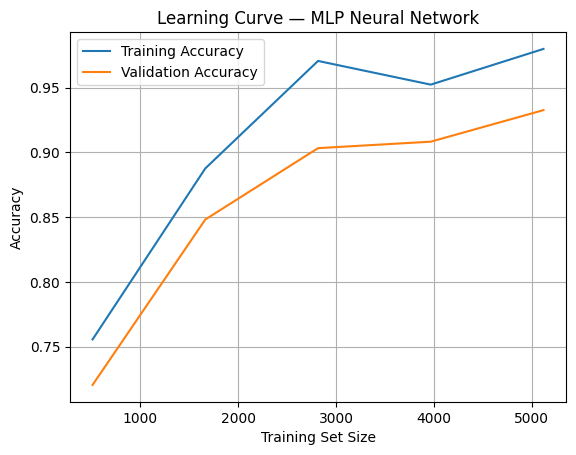

In [20]:

# Select the model with the highest cross-validation accuracy
best = max(
    [
        ("Logistic Regression", logreg_grid),
        ("SVM", svm_grid),
        ("MLP Neural Network", mlp_grid)
    ],
    key=lambda t: t[1].best_score_
)

# Function to plot learning curves
def plot_learning_curve(model, X, y, name):
    
    # Generate learning curve data using cross-validation
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=5,                                 # 5-fold cross-validation
        scoring="accuracy",                   # Evaluation metric
        n_jobs=-1,                            # Use all CPU cores
        train_sizes=np.linspace(0.1, 1.0, 5)  # Training set sizes
    )

    # Compute mean accuracy for training and validation
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    # Plot learning curves
    plt.figure()
    plt.plot(train_sizes, train_mean, label="Training Accuracy")
    plt.plot(train_sizes, val_mean, label="Validation Accuracy")
    plt.xlabel("Training Set Size")
    plt.ylabel("Accuracy")
    plt.title(f"Learning Curve — {name}")
    plt.legend()
    plt.grid()
    plt.show()

# Plot learning curve for the best-performing model
plot_learning_curve(best_models[best[0]], X_train, y_train, best[0])
